In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df_index=pd.read_csv("economic-index.csv")

In [4]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [6]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


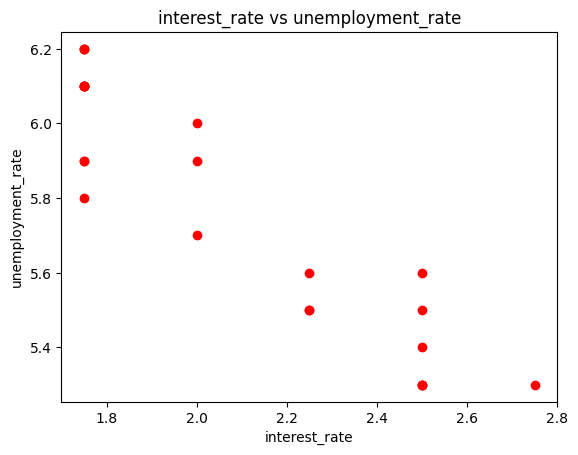

In [22]:
# visalize thedatapoints
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='red')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.title('interest_rate vs unemployment_rate')
plt.show()

In [14]:
df_index

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [16]:
x=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [17]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

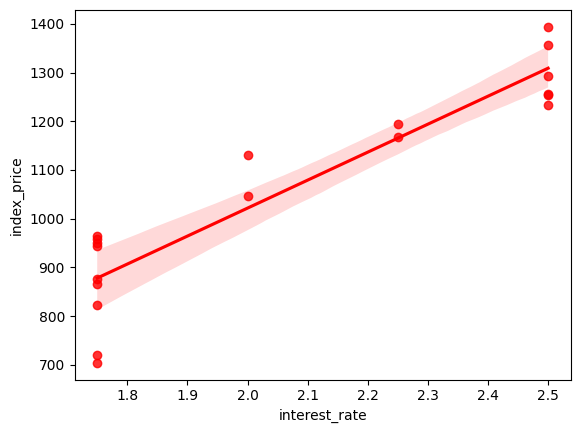

In [19]:
sns.regplot(x=x_train['interest_rate'],y=y_train,color='red')

<Axes: xlabel='interest_rate', ylabel='index_price'>

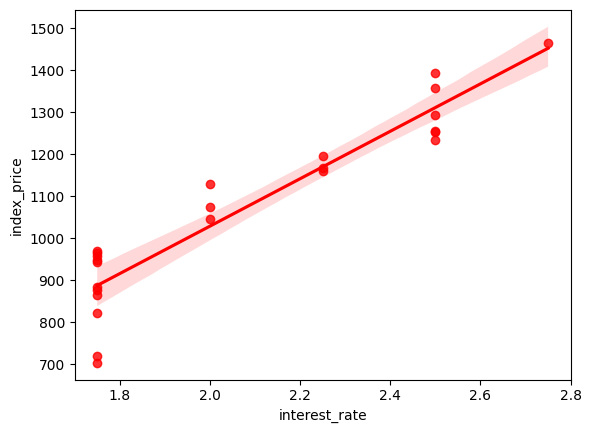

In [25]:
sns.regplot(x='interest_rate', y='index_price', data=df_index, color='red')

<Axes: xlabel='unemployment_rate', ylabel='interest_rate'>

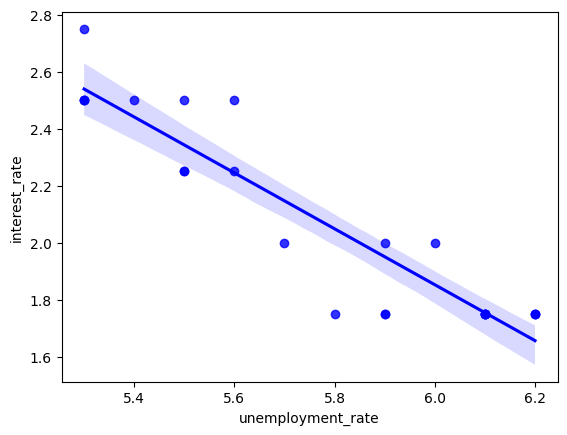

In [27]:
sns.regplot(x='unemployment_rate', y='interest_rate', data=df_index, color='blue')

In [28]:
from sklearn.preprocessing import StandardScaler


In [29]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [30]:
x_train

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [31]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [32]:
# cross validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(model,x_train,y_train,cv=5,scoring='neg_mean_squared_error')

In [33]:
validation_score

array([-1606.47408206, -9579.95329208, -7961.60935985, -8392.32547433,
        -773.2668524 ])

In [34]:
np.mean(validation_score)

np.float64(-5662.72581214445)

In [35]:
# prediction
y_pred=model.predict(x_test)

In [36]:
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [37]:
# performance evaluation
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mse,mae,rmse,r2

(6957.105303258833,
 71.71878409976625,
 np.float64(83.40926389351985),
 0.8254940547158576)

In [38]:
# adjusted r2
n=len(y_test)
p=len(x_test[0])
adj_r2=1-(1-r2)*(n-1)/(n-p-1)
adj_r2

0.6509881094317151

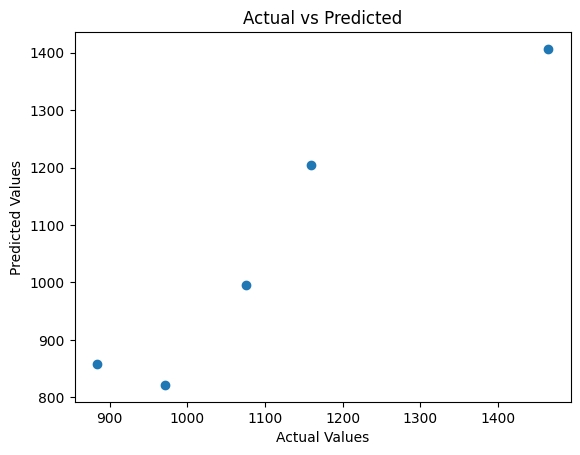

In [39]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

In [41]:
residuals=y_test-y_pred
residuals

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64

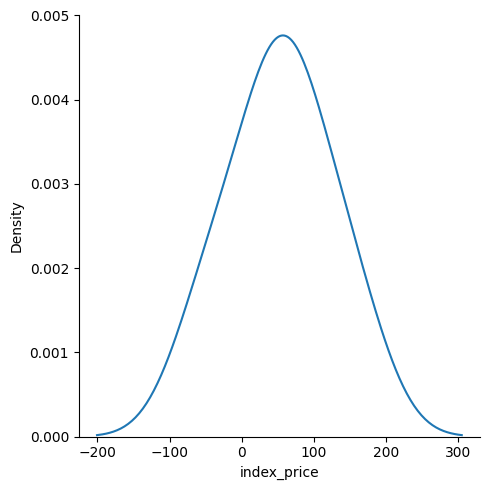

In [43]:
sns.displot(residuals,kind='kde')

Text(0, 0.5, 'Residuals')

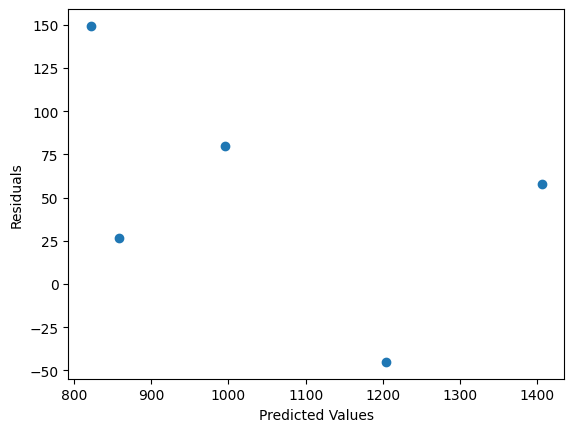

In [44]:
# scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')


In [45]:
# ols
import statsmodels.api as sm
x_ols_train=sm.OLS(x_train,y_train).fit()



In [47]:
import statsmodels.api as sm

# Ensure y_train is a 1-dimensional array
y_train_reshaped = y_train.values.reshape(-1)

# Fit the OLS model
x_ols_train = sm.OLS(y_train_reshaped, x_train).fit()

# Display the summary
x_ols_train.summary()

c:\Users\natkh\Downloads\assignment_solution\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Sat, 15 Mar 2025   Prob (F-statistic):                       0.751
Time:                        12:28:55   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
print(model.coef_)

[  86.63351334 -114.04857249]
